---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Homework 6**: Multimodal Image Search

### 📅 **Due Date**: Day of Lecture 8, 11:59 PM

### Difficulty: ★★★★☆

**Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

### Instructions

1. Use any external resource or collaborate with your classmates. But you have to cite external resources you've used and mention classmates you've collaborated with.
2. Run all cells before submitting to ensure they work.
3. Some tasks involve LLM API calls that cost money. Budget wisely.
4. I suggest you save intermediate results (descriptions, metadata) to a `temp/` folder so that you don't re-run expensive API calls.

## 1. Setup & Explore

The `data/dogs/` directory contains dog images
- These include different breeds, artistic styles (photographs, sketches, paintings, cartoons), settings, and some images with text or unusual content.

### Load and display images

Load all `.png` file paths from `data/dogs/`, sorted by name. 
- Explore the data
- How many images are there? Are they AI generated? What type of variety do you observe? What breeds do you see? What artistic styles? Any images that look unusual or have text?

Total images: 100


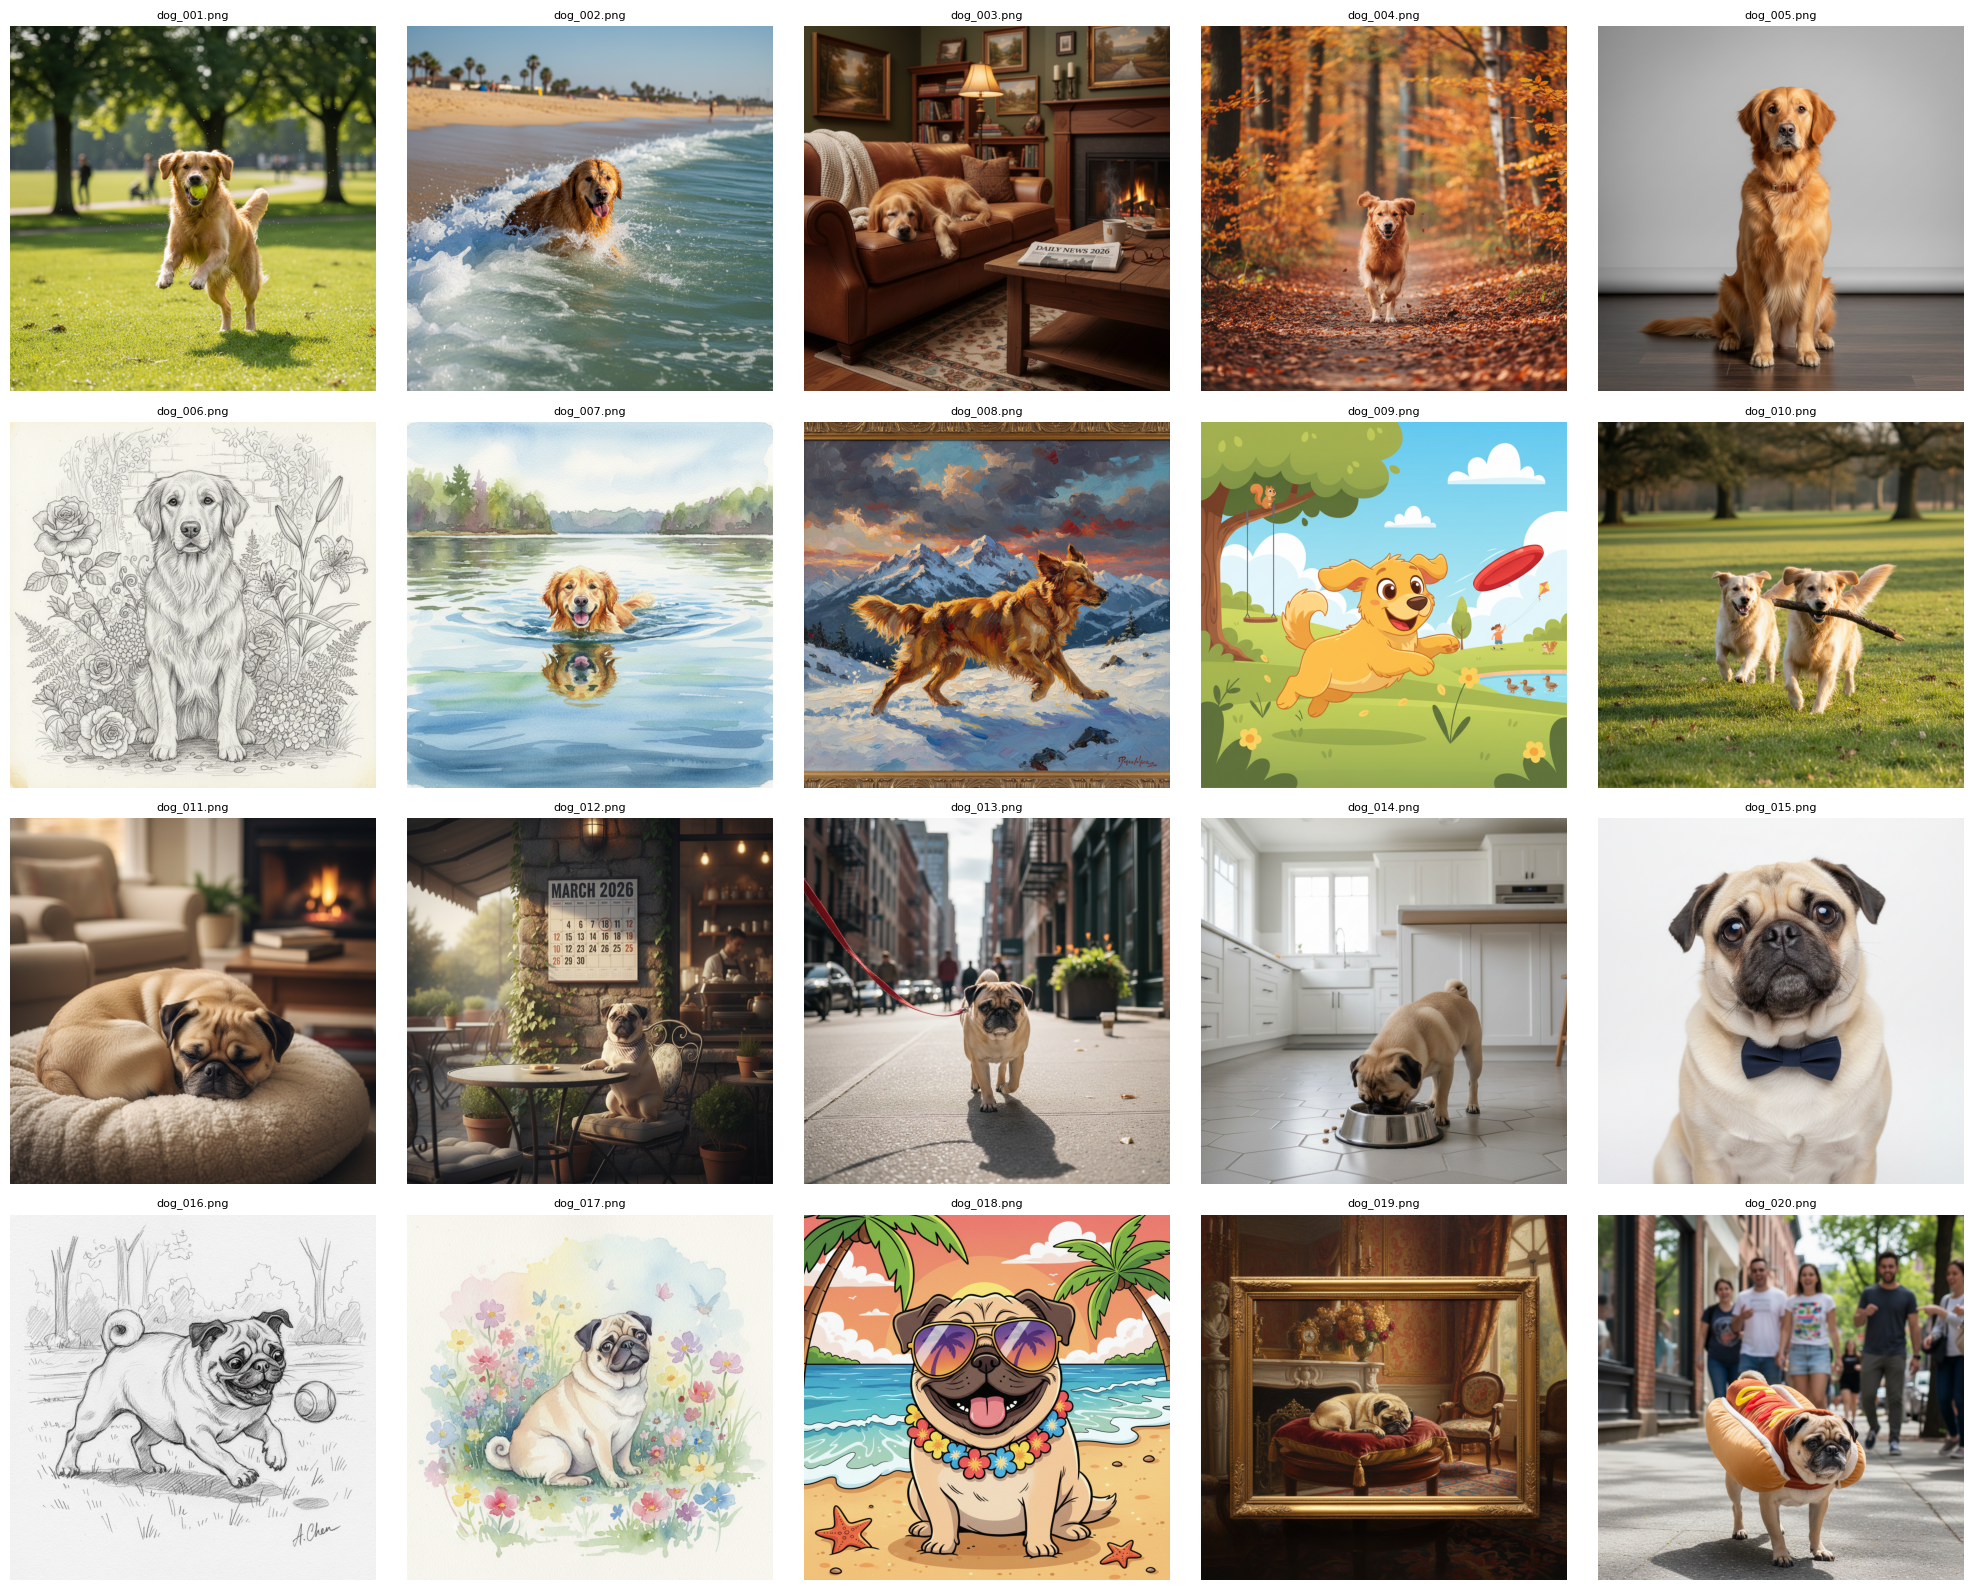

In [3]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

# Load all image paths
image_paths = sorted(Path("data/dogs").glob("*.png"))
print(f"Total images: {len(image_paths)}")

# Display first 20
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = Image.open(image_paths[i])
    ax.set_title(image_paths[i].name, fontsize=8)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. The Task

Your goal is to build a **searchable index** over these dog images that allows us to find relevant images using natural language queries, metadata filters, or both.

There are broadly two approaches:

**Approach A: Text-based pipeline**
1. Use a vision LLM to generate text descriptions of each image
2. Extract structured metadata (breed, style, setting, etc.) using an LLM with structured output
3. Embed the descriptions and build a searchable index (e.g., using LanceDB)
4. Search using semantic similarity over text + metadata filters

**Approach B: Multimodal embeddings**
1. Use a multimodal embedding model to embed the images directly
2. Embed text queries in the same space
3. Search by comparing query embeddings to image embeddings

You may combine both approaches or use a different method entirely. Use any tools from the course — `litellm`, `lancedb`, `pydantic`, `sentence-transformers` - or any other tools you want.


In [5]:
import os
import json
import base64
from pathlib import Path
from openai import OpenAI

client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

Path("temp").mkdir(exist_ok=True)
DESCRIPTIONS_FILE = Path("temp/descriptions.json")

def encode_image(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def describe_image(image_path):
    b64 = encode_image(image_path)
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[{
            "role": "user",
            "content": [
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}},
                {"type": "text", "text": "Describe this dog image in 2-3 sentences. Include the breed, artistic style (photo, cartoon, sketch, painting, etc.), setting, and what the dog is doing."}
            ]
        }],
        max_tokens=200
    )
    return response.choices[0].message.content

if DESCRIPTIONS_FILE.exists():
    print("Loading existing descriptions...")
    descriptions = json.loads(DESCRIPTIONS_FILE.read_text())
else:
    print("Generating descriptions for 100 images...")
    descriptions = {}
    for i, path in enumerate(image_paths):
        descriptions[path.name] = describe_image(path)
        if (i+1) % 10 == 0:
            print(f"{i+1}/100 done")
    DESCRIPTIONS_FILE.write_text(json.dumps(descriptions, indent=2))
    print("Done! Saved to temp/descriptions.json")

print(f"Total descriptions: {len(descriptions)}")
print("\nExample:", list(descriptions.items())[0])

Generating descriptions for 100 images...
10/100 done
20/100 done
30/100 done
40/100 done
50/100 done
60/100 done
70/100 done
80/100 done
90/100 done
100/100 done
Done! Saved to temp/descriptions.json
Total descriptions: 100

Example: ('dog_001.png', 'The image is a photograph of a Golden Retriever joyfully playing in a grassy park. The dog is captured mid-leap with a tennis ball in its mouth, surrounded by a backdrop of trees and a sunny day. The scene conveys a sense of energy and happiness.')


In [6]:
from pydantic import BaseModel
from openai import OpenAI
import json
from pathlib import Path

METADATA_FILE = Path("temp/metadata.json")

class DogMetadata(BaseModel):
    breed: str
    style: str  # photo, cartoon, sketch, painting, etc.
    setting: str  # beach, park, living room, etc.
    action: str  # sitting, running, eating, etc.
    has_text: bool

def extract_metadata(filename, description):
    response = client.beta.chat.completions.parse(
        model="gpt-4o",
        messages=[{
            "role": "user",
            "content": f"Extract structured metadata from this dog image description:\n\n{description}"
        }],
        response_format=DogMetadata
    )
    return response.choices[0].message.parsed.model_dump()

if METADATA_FILE.exists():
    print("Loading existing metadata...")
    metadata = json.loads(METADATA_FILE.read_text())
else:
    print("Extracting metadata...")
    metadata = {}
    for i, (filename, description) in enumerate(descriptions.items()):
        metadata[filename] = extract_metadata(filename, description)
        if (i+1) % 10 == 0:
            print(f"{i+1}/100 done")
    METADATA_FILE.write_text(json.dumps(metadata, indent=2))
    print("Done! Saved to temp/metadata.json")

print(f"Total metadata: {len(metadata)}")
print("\nExample:", list(metadata.items())[0])

Extracting metadata...
10/100 done
20/100 done
30/100 done
40/100 done
50/100 done
60/100 done
70/100 done
80/100 done
90/100 done
100/100 done
Done! Saved to temp/metadata.json
Total metadata: 100

Example: ('dog_001.png', {'breed': 'Golden Retriever', 'style': 'Photograph', 'setting': 'Grassy park surrounded by trees on a sunny day', 'action': 'Joyfully playing, captured mid-leap with a tennis ball in its mouth', 'has_text': False})


In [11]:
import sys
!{sys.executable} -m pip install lancedb sentence-transformers

In [12]:
import lancedb
import numpy as np
from sentence_transformers import SentenceTransformer

# Load embedding model
print("Loading embedding model...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# Build records
print("Building records...")
records = []
for filename in image_paths:
    name = filename.name
    desc = descriptions.get(name, "")
    meta = metadata.get(name, {})
    embedding = embedder.encode(desc).tolist()
    records.append({
        "filename": name,
        "description": desc,
        "breed": meta.get("breed", "unknown"),
        "style": meta.get("style", "unknown"),
        "setting": meta.get("setting", "unknown"),
        "action": meta.get("action", "unknown"),
        "has_text": meta.get("has_text", False),
        "vector": embedding
    })

# Create LanceDB table
db = lancedb.connect("temp/lancedb")
if "dogs" in db.table_names():
    db.drop_table("dogs")
table = db.create_table("dogs", records)
print(f"Index built with {len(records)} records!")

/Users/suhaniwadhwa/ai-engineering-fordham/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading embedding model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2428.05it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Building records...
Index built with 100 records!


/var/folders/f9/dnqqvw1j3nq5jsq8zqx__plm0000gn/T/ipykernel_40357/41488710.py:30: DeprecationWarning: table_names() is deprecated, use list_tables() instead
  if "dogs" in db.table_names():


In [13]:
def query_index(query, filter=None, k=5):
    query_vector = embedder.encode(query).tolist()
    
    results = table.search(query_vector).limit(k)
    
    if filter:
        results = results.where(filter)
    
    results = results.to_list()
    
    return [{
        "filename": r["filename"],
        "breed": r["breed"],
        "style": r["style"],
        "setting": r["setting"],
        "action": r["action"],
        "description": r["description"],
        "score": r["_distance"]
    } for r in results]

# Quick test
results = query_index("a happy dog at the beach")
for r in results:
    print(r["filename"], "|", r["breed"], "|", r["score"])

dog_002.png | Golden Retriever | 0.6933809518814087
dog_096.png | Poodle | 0.7978535294532776
dog_084.png | Beagle | 0.8007866144180298
dog_042.png | Pembroke Welsh Corgi | 0.828916072845459
dog_027.png | German Shepherd | 0.908608078956604


## 3. Your Own Queries

To make a good search system, you will need to come up with some of your own queries and "golden" answers to these queries to evaluate your system with. Show us your work.


Query: 'dog picture from 2025'
  dog_053.png | breed: Dalmatian | style: photograph | score: 0.6268
  dog_083.png | breed: Beagle | style: Photograph | score: 0.7857
  dog_073.png | breed: Shiba Inu | style: Photograph | score: 0.8089


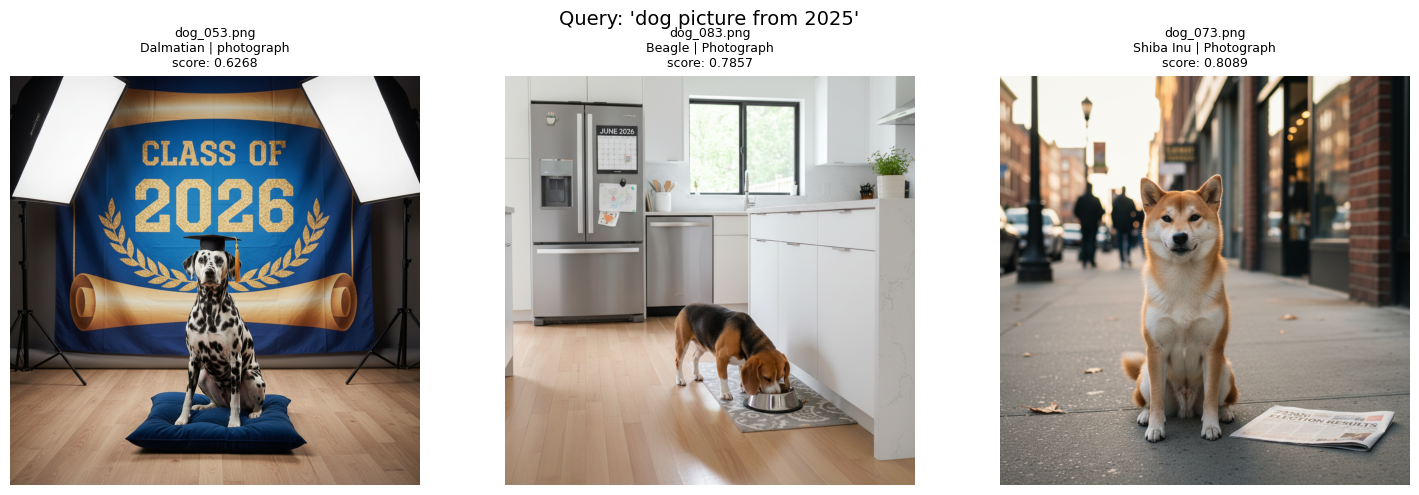

In [17]:
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt

my_queries = ["dog picture from 2025"]

for query in my_queries:
    print(f"\nQuery: '{query}'")
    results = query_index(query, k=3)
    for r in results:
        print(f"  {r['filename']} | breed: {r['breed']} | style: {r['style']} | score: {r['score']:.4f}")
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Query: '{query}'", fontsize=14)
    for i, r in enumerate(results):
        img = Image.open(f"data/dogs/{r['filename']}")
        axes[i].imshow(img)
        axes[i].set_title(f"{r['filename']}\n{r['breed']} | {r['style']}\nscore: {r['score']:.4f}", fontsize=9)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

## 4. Evaluation Queries

We will evaluate your index by running queries against it — queries similar in spirit to the examples below, but not identical.

**Important:** Define a function called `query_index(query, filter=None, k=5)` that takes a natural language query, an optional metadata filter string (e.g., `"breed = 'pug'"`), and returns the top-k results as a list of dicts with at least a `"filename"` key. We will call this function to test your system.

### Example semantic queries
1. `"a happy dog at the beach"`
2. `"a dog sitting in a cafe"`
3. `"a pencil drawing of a dog"`

### Example filtered queries
4. Find all **corgi** images — `query_index("dog", filter="breed = 'corgi'", k=20)`
5. Find all **cartoon** images
6. Find all images set in a **living room**
7. Find all images where the dog is **eating**

### Example combined queries
8. `"dog in the snow"` among **huskies** only
9. `"cute dog posing"` among **pencil sketches** only
10. `"running on the beach"` among **dalmatians** only

Run these example queries and display results clearly — filenames, metadata, and scores.

In [15]:
# Section 4: Evaluation Queries

# 1. Semantic queries
print("=== SEMANTIC QUERIES ===\n")

queries = [
    "a happy dog at the beach",
    "a dog sitting in a cafe",
    "a pencil drawing of a dog"
]

for q in queries:
    print(f"Query: '{q}'")
    results = query_index(q, k=3)
    for r in results:
        print(f"  {r['filename']} | breed: {r['breed']} | style: {r['style']} | score: {r['score']:.4f}")
    print()

# 2. Filtered queries
print("=== FILTERED QUERIES ===\n")

print("All corgis:")
for r in query_index("dog", filter="breed = 'corgi'", k=20):
    print(f"  {r['filename']} | {r['breed']}")

print("\nAll cartoons:")
for r in query_index("dog", filter="style = 'cartoon'", k=20):
    print(f"  {r['filename']} | {r['style']}")

print("\nAll living room:")
for r in query_index("dog", filter="setting = 'living room'", k=20):
    print(f"  {r['filename']} | {r['setting']}")

print("\nDogs eating:")
for r in query_index("dog", filter="action = 'eating'", k=20):
    print(f"  {r['filename']} | {r['action']}")

# 3. Combined queries
print("\n=== COMBINED QUERIES ===\n")

print("Dog in snow + husky:")
for r in query_index("dog in the snow", filter="breed = 'husky'", k=5):
    print(f"  {r['filename']} | {r['breed']} | score: {r['score']:.4f}")

print("\nCute dog posing + pencil sketch:")
for r in query_index("cute dog posing", filter="style = 'pencil sketch'", k=5):
    print(f"  {r['filename']} | {r['style']} | score: {r['score']:.4f}")

print("\nRunning on beach + dalmatian:")
for r in query_index("running on the beach", filter="breed = 'dalmatian'", k=5):
    print(f"  {r['filename']} | {r['breed']} | score: {r['score']:.4f}")

=== SEMANTIC QUERIES ===

Query: 'a happy dog at the beach'
  dog_002.png | breed: Golden Retriever | style: photograph | score: 0.6934
  dog_096.png | breed: Poodle | style: detailed sketch | score: 0.7979
  dog_084.png | breed: Beagle | style: Photograph | score: 0.8008

Query: 'a dog sitting in a cafe'
  dog_078.png | breed: Shiba Inu | style: cartoon | score: 0.8419
  dog_044.png | breed: Pembroke Welsh Corgi | style: Photograph | score: 0.9152
  dog_063.png | breed: English Bulldog | style: Photo | score: 0.9259

Query: 'a pencil drawing of a dog'
  dog_026.png | breed: German Shepherd | style: Realistic textures and shading | score: 0.6138
  dog_086.png | breed: Beagle | style: detailed pencil sketch | score: 0.6527
  dog_066.png | breed: English Bulldog | style: pencil sketch | score: 0.7514

=== FILTERED QUERIES ===

All corgis:
  dog_048.png | corgi

All cartoons:
  dog_069.png | cartoon
  dog_009.png | cartoon
  dog_048.png | cartoon
  dog_088.png | cartoon
  dog_078.png | ca

## 5. Submission

- [ ] Create a new branch called `homework-6`
- [ ] Commit and push your work (notebook + CSV files in `temp/`)
- [ ] Create a Pull Request
- [ ] Merge the PR to main
- [ ] Submit the `.ipynb` file on Blackboard

**Note:** Commit the notebook and the `temp/` files that your code created.